# Store tals lov

Ifølge Den store Dansk er store tals lov

"De store tals lov, fundamentalt resultat i sandsynlighedsregning, der siger, at hvis X₁, X₂,... er en uendelig følge af uafhængige, tilfældige tal med samme fordeling med middelværdi μ, vil gennemsnittet (X₁+∙∙∙+Xₙ)/n for n gående mod uendelig konvergere mod μ. Fx vil i en uendelig serie af møntkast, hvor plat og krone er lige sandsynlige, hyppigheden af de kast blandt de første n, der viser krone, være tæt på 1/2 for n stor."

### Øvelse
* Beskriv hvad det betyder at tallene er tilfældige med samme fordeling.
* Beskriv hvad det betyder at de er uafhængige.
* Beskriv hvad det betyder at gennemsnittet konvergerer mod $\mu$.

I praksis er det selvfølgeligt ikke muligt at have uendeligt mange observationer.
Vi vil i det efterfølgende undersøge hvad antagelsen om uafhængighed betyder for Store tals lov.

## Uafhængige variable

Programmet genererer binomialfordelte variable, **X** og beregner gennemsnittet, **Xmean**.

In [1]:
%%capture
# Tjek om vi kører i Google Colab
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    # 1. Clone hele dit repository for at få adgang til datafiler og billeder
    !git clone https://github.com/mpsteenstrup/simuleringerOgFordeliger.git
    %cd simuleringerOgFordeliger
    
    # 2. Installer nødvendige pakker fra din requirements.txt
    # (Hvis du har en requirements.txt i dit repo)
    !pip install -r requirements.txt

In [2]:
import matplotlib.pyplot as plt
import random
import numpy as np

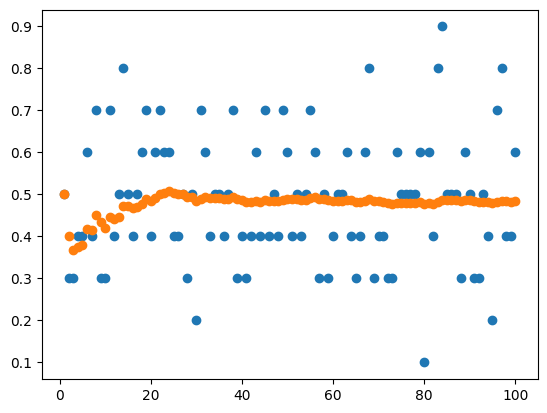

[0.5, 0.3, 0.3, 0.4, 0.4, 0.6, 0.4, 0.7, 0.3, 0.3, 0.7, 0.4, 0.5, 0.8, 0.5, 0.4, 0.5, 0.6, 0.7, 0.4, 0.6, 0.7, 0.6, 0.6, 0.4, 0.4, 0.5, 0.3, 0.5, 0.2, 0.7, 0.6, 0.4, 0.5, 0.5, 0.4, 0.5, 0.7, 0.3, 0.4, 0.3, 0.4, 0.6, 0.4, 0.7, 0.4, 0.5, 0.4, 0.7, 0.6, 0.4, 0.5, 0.4, 0.5, 0.7, 0.6, 0.3, 0.5, 0.3, 0.4, 0.5, 0.5, 0.6, 0.4, 0.3, 0.4, 0.6, 0.8, 0.3, 0.4, 0.4, 0.3, 0.3, 0.6, 0.5, 0.5, 0.5, 0.5, 0.6, 0.1, 0.6, 0.4, 0.8, 0.9, 0.5, 0.5, 0.5, 0.3, 0.6, 0.5, 0.3, 0.3, 0.5, 0.4, 0.2, 0.7, 0.8, 0.4, 0.4, 0.6]
[0.5, 0.4, 0.3666666666666667, 0.375, 0.38, 0.4166666666666667, 0.41428571428571426, 0.45, 0.43333333333333335, 0.42000000000000004, 0.4454545454545455, 0.44166666666666665, 0.4461538461538461, 0.4714285714285714, 0.47333333333333333, 0.46875, 0.47058823529411764, 0.47777777777777775, 0.48947368421052634, 0.485, 0.4904761904761905, 0.5, 0.5043478260869565, 0.5083333333333333, 0.504, 0.5, 0.5, 0.4928571428571429, 0.4931034482758621, 0.48333333333333334, 0.49032258064516127, 0.49375, 0.4909090909

In [3]:
X = []
Xmean = []

def bin(n, p):
    x = 0
    for i in range(0, n):
        r = random.random()
        if r <= p:
            x = x + 1
    return x / n

# her genereres 100 realiseringer af en variable X antalsparameter n,
# og sandsynlighedsparameteren, p, bin(n,p)
for k in range(0, 100):
    X.append(bin(10, 0.5))

# Beregninger
for j in range(1, len(X) + 1):
    Xmean.append(sum(X[0:j]) / j)

# Plotting
plt.plot(range(1, len(X) + 1), X, 'o')
plt.plot(range(1, len(Xmean) + 1), Xmean, 'o')
plt.show()

# Output
print(X)
print(Xmean)

### Øvelse
* Kør programmet og beskriv i ord hvordan du kan se Store tals lov.
* Lav om i linjen så du får færre tal, hvornår gælder STL?
* Prøv at lave om på antals eller sandsynlighedsparametren og se om STL stadig holder.
* Argumenter for at *X* kan fortolkes som sandsynligheden for krone.
* Kopier evt. data ind i Maple og tjek for normalfordeling.

## Afhængige variable

En af betingelserne for STL er at observationerne er uafhængige. I nedenstående simulation har vi tilføjet
```python
if r <= p:
    x = x + 1
    p += 0.0001
else:
    p -= 0.0001
```
sandsynligheden for krone, **p**, afhænger nu af om vi tidligere har fået krone. For hver krone bliver sandsynligheden 0.0001 større mens den ved plat bliver 0.0001 mindre. I simuleringen bliver **p** ført videre til næste stokastiske variabel, så den starter med en sandsynlighedsparameter som den forrige sluttede med.

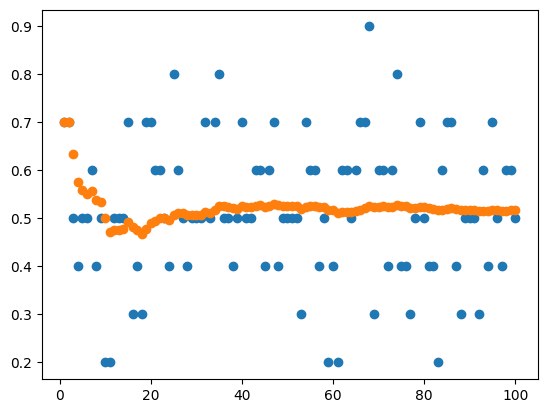

[0.7, 0.7, 0.5, 0.4, 0.5, 0.5, 0.6, 0.4, 0.5, 0.2, 0.2, 0.5, 0.5, 0.5, 0.7, 0.3, 0.4, 0.3, 0.7, 0.7, 0.6, 0.6, 0.5, 0.4, 0.8, 0.6, 0.5, 0.4, 0.5, 0.5, 0.5, 0.7, 0.5, 0.7, 0.8, 0.5, 0.5, 0.4, 0.5, 0.7, 0.5, 0.5, 0.6, 0.6, 0.4, 0.6, 0.7, 0.4, 0.5, 0.5, 0.5, 0.5, 0.3, 0.7, 0.6, 0.6, 0.4, 0.5, 0.2, 0.4, 0.2, 0.6, 0.6, 0.5, 0.6, 0.7, 0.7, 0.9, 0.3, 0.6, 0.6, 0.4, 0.6, 0.8, 0.4, 0.4, 0.3, 0.5, 0.7, 0.5, 0.4, 0.4, 0.2, 0.6, 0.7, 0.7, 0.4, 0.3, 0.5, 0.5, 0.5, 0.3, 0.6, 0.4, 0.7, 0.5, 0.4, 0.6, 0.6, 0.5]
[0.7, 0.7, 0.6333333333333333, 0.575, 0.5599999999999999, 0.5499999999999999, 0.5571428571428572, 0.5375, 0.5333333333333333, 0.5, 0.4727272727272727, 0.47500000000000003, 0.47692307692307695, 0.4785714285714286, 0.49333333333333335, 0.48125, 0.4764705882352941, 0.4666666666666667, 0.4789473684210526, 0.49000000000000005, 0.49523809523809526, 0.5, 0.5, 0.49583333333333335, 0.508, 0.5115384615384616, 0.5111111111111112, 0.5071428571428571, 0.506896551724138, 0.5066666666666666, 0.506451612903225

In [4]:
X = []
Xmean = []
p = 0.5

def bin_dependent(n, p):
    x = 0
    for i in range(0, n):
        r = random.random()
        if r <= p:
            x = x + 1
            p += 0.0001
        else:
            p -= 0.0001
    return x / n, p

# her genereres 100 realiseringer af en variable X med afhængighed
for k in range(0, 100):
    result, p = bin_dependent(10, p)
    X.append(result)

# Beregninger
for j in range(1, len(X) + 1):
    Xmean.append(sum(X[0:j]) / j)

# Plotting
plt.plot(range(1, len(X) + 1), X, 'o')
plt.plot(range(1, len(Xmean) + 1), Xmean, 'o')
plt.show()

# Output
print(X)
print(Xmean)

### Øvelse
* Kør simuleringen og beskriv hvad du ser.
* Argumenter for hvorfor gennemsnittet ikke konvergerer mod en middelværdi.
* Undersøg hvor meget ændringen i **p** betyder for STL.
* Prøv at bytte så en krone nu ændrer sandsynligheden negativt.